<a href="https://colab.research.google.com/github/bhavananamburi/oasis-infobyte-internship-/blob/main/Bhavana_task2_Customer_Segmentation_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **Loading the Data**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving ifood_df.csv to ifood_df.csv


In [ ]:
df = pd.read_csv('ifood_df.csv')

In [ ]:
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

In [ ]:
df.isnull().sum()

,0
Income,0
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0
MntFishProducts,0
MntSweetProducts,0
MntGoldProds,0


In [ ]:
df['MntTotal'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)
df['MntTotal'].head()

,MntTotal
0,1617
1,27
2,776
3,53
4,422


**Descriptive Statistics**

In [ ]:
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,606.821769,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,601.675284,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,397.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1047.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2525.000000,2458.000000,4.00000


**Mean**

In [ ]:
print("Mean")
print(df[['Income', 'MntTotal', 'NumWebPurchases', 'NumStorePurchases', 'Age']].mean())

Mean
Income               51622.094785
MntTotal               606.821769
NumWebPurchases          4.100680
NumStorePurchases        5.823583
Age                     51.095692
dtype: float64


**Median**

In [ ]:
print("\nMedian")
print(df[['Income', 'MntTotal', 'NumWebPurchases', 'NumStorePurchases', 'Age']].median())


Median
Income               51287.0
MntTotal               397.0
NumWebPurchases          4.0
NumStorePurchases        5.0
Age                     50.0
dtype: float64


**Mode**

In [ ]:
print("\nMode")
print(df[['Income', 'MntTotal', 'NumWebPurchases', 'NumStorePurchases', 'Age']].mode().iloc[0])


Mode
Income               7500.0
MntTotal               46.0
NumWebPurchases         2.0
NumStorePurchases       3.0
Age                    44.0
Name: 0, dtype: float64


**Standard Deviation**

In [ ]:
print("\nStandard Deviation")
print(df[['Income', 'MntTotal', 'NumWebPurchases', 'NumStorePurchases', 'Age']].std())


Standard Deviation
Income               20713.063826
MntTotal               601.675284
NumWebPurchases          2.737424
NumStorePurchases        3.241796
Age                     11.705801
dtype: float64


# **Customer Spending Analysis**

In [ ]:
df.columns

Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married',
       'marital_Single', 'marital_Together', 'marital_Widow',
       'education_2n Cycle', 'education_Basic', 'education_Graduation',
       'education_Master', 'education_PhD', 'MntTotal', 'MntRegularProds',
       'AcceptedCmpOverall'],
      dtype='object')

In [ ]:
print(df.columns.tolist())

['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married', 'marital_Single', 'marital_Together', 'marital_Widow', 'education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD', 'MntTotal', 'MntRegularProds', 'AcceptedCmpOverall']


**Total Sales by Product Category**

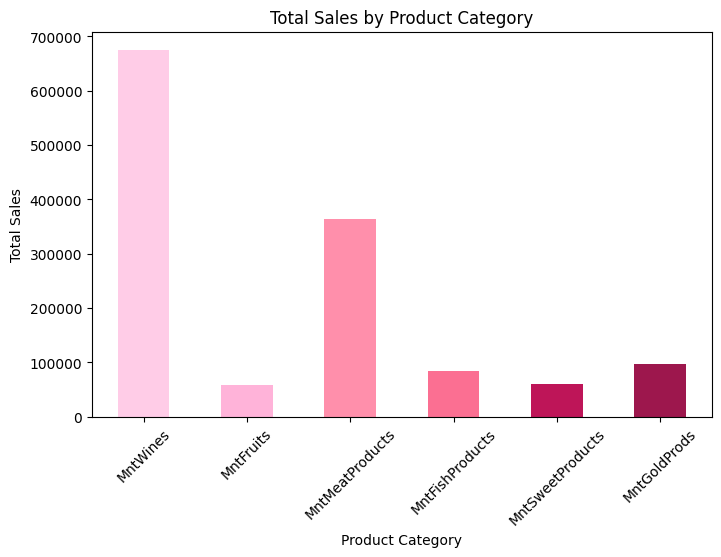

In [ ]:
products = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

product_sales = df[products].sum()

plt.figure(figsize=(8,5))
product_sales.plot(kind='bar', color=['#ffcce7', '#ffb3d9','#ff8fab', '#fb6f92','#be1558', '#9D174D'])
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

**Income Distribution**

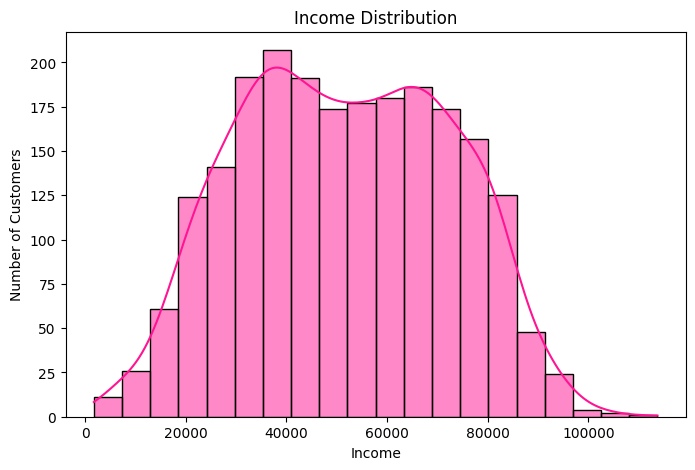

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Income'], bins=20, kde=True, color='#FF1493')
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Customers")
plt.show()

**Customer Age Distribution**

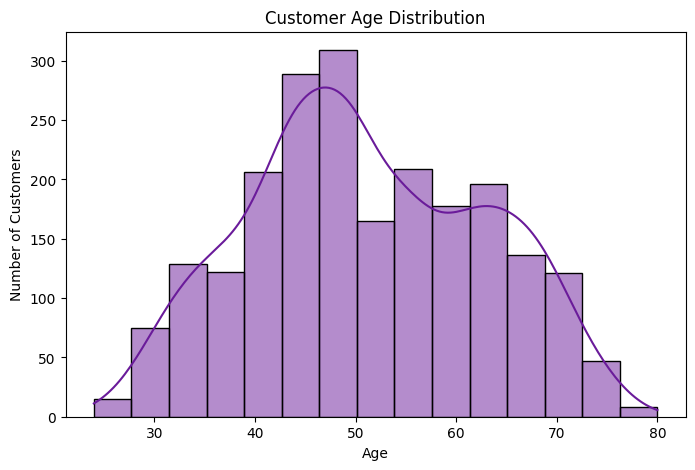

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=15, kde=True, color= '#6A1B9A')
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

**Average Spending**

In [ ]:
print("Average Spending")
print(df['MntTotal'].mean())

Average Spending
606.821768707483


**Purchase Frequency**

In [ ]:
print("Average Web Purchases")
print(df['NumWebPurchases'].mean())

print("Average Store Purchases")
print(df['NumStorePurchases'].mean())

Average Web Purchases
4.100680272108844
Average Store Purchases
5.823582766439909


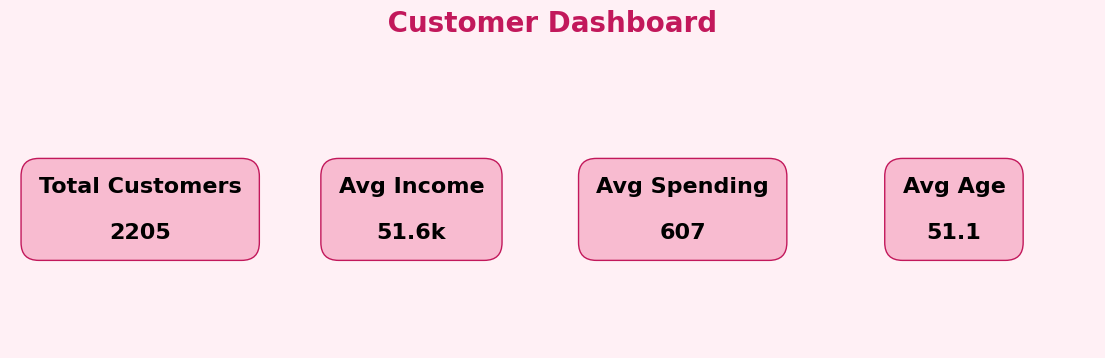

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14,4))
ax.axis('off')
fig.patch.set_facecolor('#FFF0F5')

plt.title(" Customer Dashboard ",
          fontsize=20,
          fontweight='bold',
          color='#C2185B')

cards = [
    ("Total Customers", len(df)),
    ("Avg Income", f"{df['Income'].mean()/1000:.1f}k"),
    ("Avg Spending", f"{df['MntTotal'].mean():.0f}"),
    ("Avg Age", f"{df['Age'].mean():.1f}")
]

for x, (label, value) in zip([0.12, 0.37, 0.62, 0.87], cards):
    ax.text(
        x, 0.45,
        f"{label}\n\n{value}",
        ha='center',
        va='center',
        fontsize=16,
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.8',
            facecolor='#F8BBD0',
            edgecolor='#C2185B'
        )
    )
plt.show()

# **Customer Segmentation**

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
features = df[[
    'Income',
    'MntTotal',
    'NumWebPurchases',
    'NumStorePurchases'
]]

features.head()

,Income,MntTotal,NumWebPurchases,NumStorePurchases
0,58138.0,1617,8,4
1,46344.0,27,1,2
2,71613.0,776,8,10
3,26646.0,53,2,4
4,58293.0,422,5,6


In [ ]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

 **Elbow Method**

In [ ]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

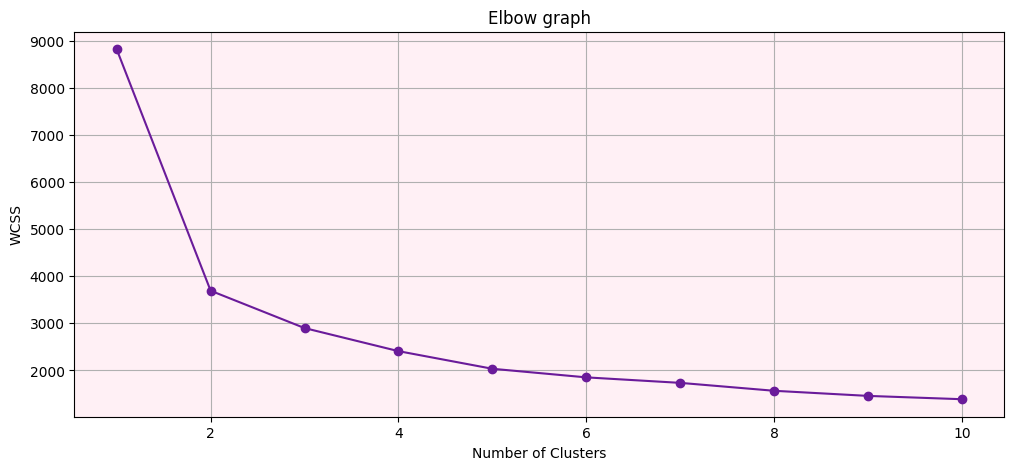

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o',
    color= '#6A1B9A'
)
plt.gca().set_facecolor('#FFF0F5')
plt.title("Elbow graph")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(
    scaled_features
)
df[['Income','MntTotal','Cluster']].head()

,Income,MntTotal,Cluster
0,58138.0,1617,2
1,46344.0,27,1
2,71613.0,776,2
3,26646.0,53,1
4,58293.0,422,3


# **Visualization**

**customer segmentation** (Scatter Plot)

In [ ]:

cluster_summary = df.groupby("Cluster")[[
    "Income",
    "MntTotal",
    "NumWebPurchases",
    "NumStorePurchases"
]].mean().round(2)

print(cluster_summary)

           Income  MntTotal  NumWebPurchases  NumStorePurchases
Cluster                                                        
0        76988.31   1445.87             4.29               8.57
1        32179.09     74.44             1.79               2.97
2        65078.75   1018.99             8.17               9.16
3        52345.32    447.86             4.93               5.76


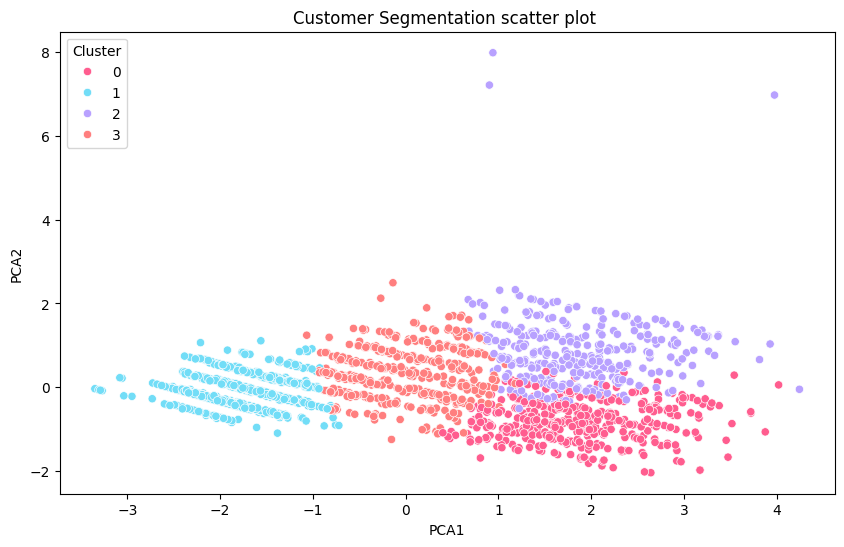

In [ ]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(
    scaled_features
)

df['PCA1'] = pca_features[:,0]
df['PCA2'] = pca_features[:,1]
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=df,
    palette=['#ff5d8f', '#72ddf7', '#b8a1ff', '#ff7f7f']
)

plt.title("Customer Segmentation scatter plot ")

plt.show()

**Average Spending by Customer Segment** (bar chart)

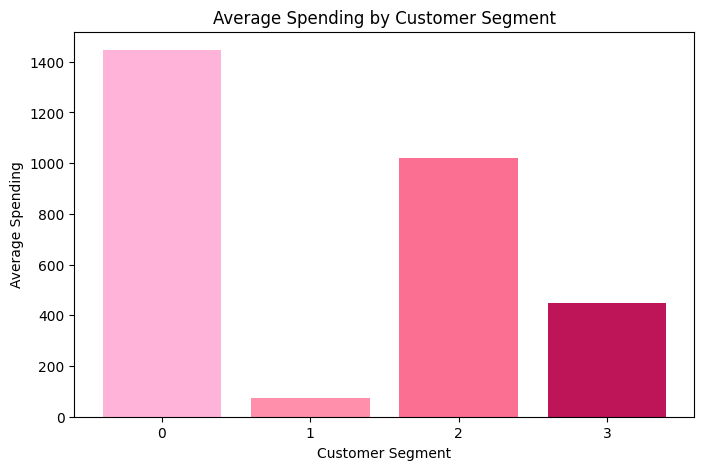

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    cluster_summary.index.astype(str),
    cluster_summary["MntTotal"],
    color=['#ffb3d9', '#ff8fab', '#fb6f92', '#be1558']
)

plt.xlabel("Customer Segment")
plt.ylabel("Average Spending")
plt.title("Average Spending by Customer Segment")

plt.show()

 **Customer Segment Distribution**

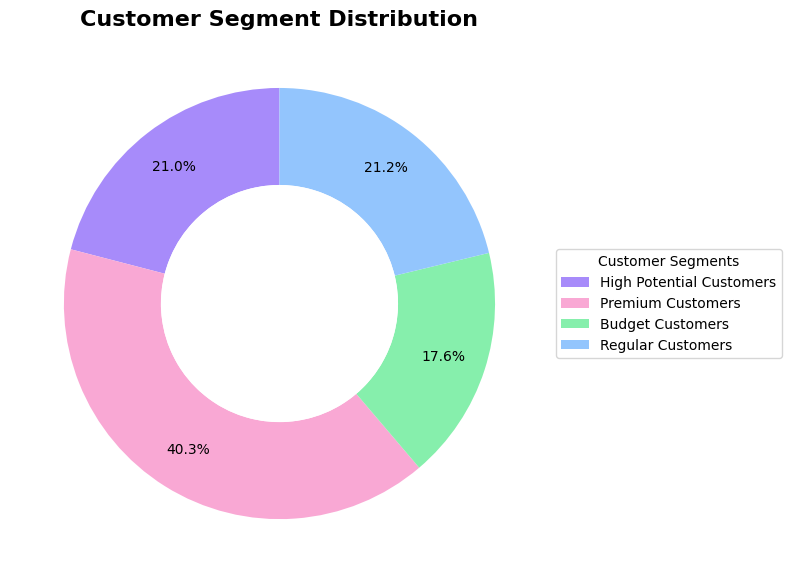

In [ ]:
cluster_counts = df['Cluster'].value_counts().sort_index()

labels = [
    'High Potential Customers',
    'Premium Customers',
    'Budget Customers',
    'Regular Customers'
]

colors = ['#A78BFA', '#F9A8D4', '#86EFAC', '#93C5FD']

plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    cluster_counts,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.8,
    wedgeprops={'width': 0.45}
)

plt.legend(
    wedges,
    labels,
    title='Customer Segments',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

plt.title('Customer Segment Distribution', fontsize=16, fontweight='bold')

centre_circle = plt.Circle((0, 0), 0.55, fc='white')
plt.gca().add_artist(centre_circle)

plt.tight_layout()
plt.show()

**Income vs Spending by Customer**

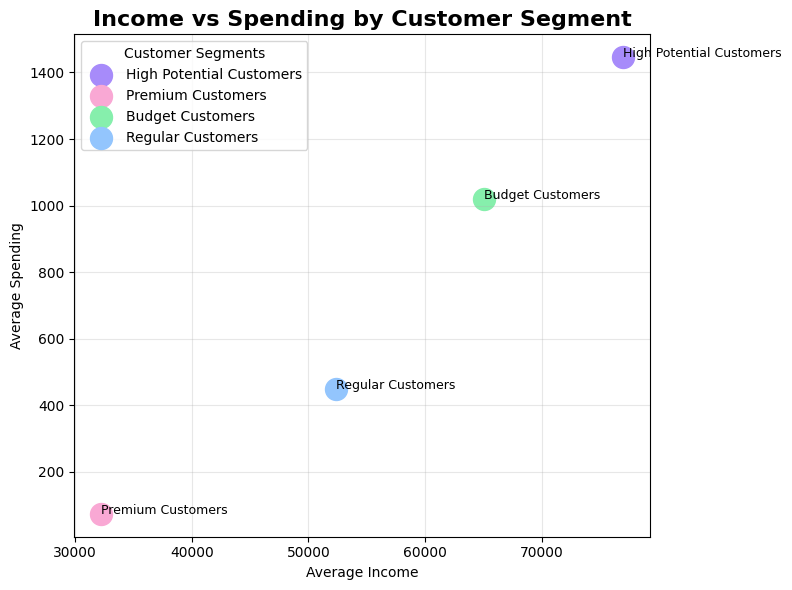

In [ ]:

cluster_summary = df.groupby("Cluster")[["Income", "MntTotal"]].mean().round(0)

colors = ['#A78BFA', '#F9A8D4', '#86EFAC', '#93C5FD']

plt.figure(figsize=(8, 6))

for i, cluster in enumerate(cluster_summary.index):
    plt.scatter(
        cluster_summary.loc[cluster, "Income"],
        cluster_summary.loc[cluster, "MntTotal"],
        s=250,
        color=colors[i],
        label=labels[cluster]
    )

    plt.text(
        cluster_summary.loc[cluster, "Income"],
        cluster_summary.loc[cluster, "MntTotal"],
        labels[cluster],
        fontsize=9,
        ha="left"
    )

plt.title("Income vs Spending by Customer Segment", fontsize=16, fontweight="bold")
plt.xlabel("Average Income")
plt.ylabel("Average Spending")
plt.grid(alpha=0.3)
plt.legend(title="Customer Segments")
plt.tight_layout()
plt.show()

# **Heatmap Analysis**

**Correlation Matrix**

In [ ]:
corr = df[[
    'Income',
    'MntTotal',
    'NumWebPurchases',
    'NumStorePurchases'
]].corr()

corr



,Income,MntTotal,NumWebPurchases,NumStorePurchases
Income,1.000000,0.823770,0.503184,0.687206
MntTotal,0.823770,1.000000,0.533702,0.682306
NumWebPurchases,0.503184,0.533702,1.000000,0.512109
NumStorePurchases,0.687206,0.682306,0.512109,1.000000


**Heatmap**

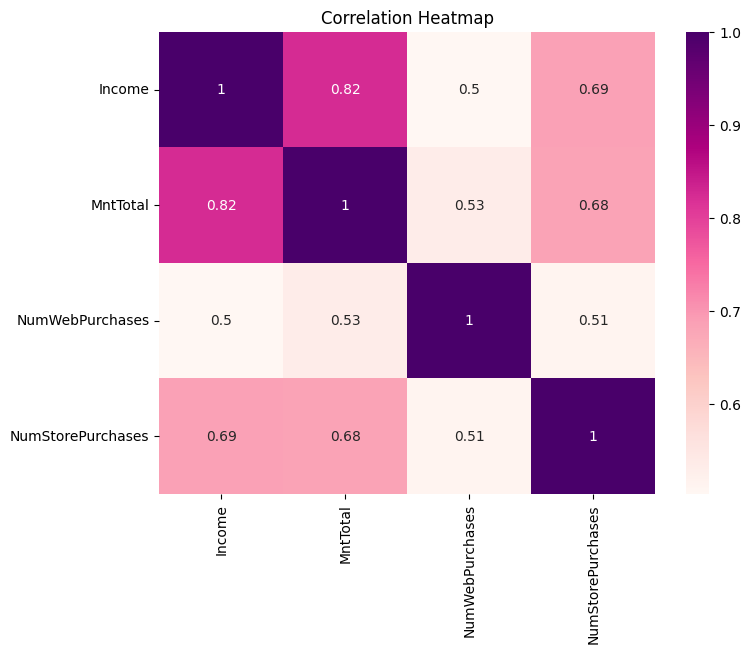

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdPu'
)

plt.title("Correlation Heatmap")

plt.show()

# **Cluster Analysis**

In [ ]:
cluster_summary = df.groupby(
    'Cluster'
)[[
    'Income',
    'MntTotal',
    'NumWebPurchases',
    'NumStorePurchases'
]].mean()

print(cluster_summary)

               Income     MntTotal  NumWebPurchases  NumStorePurchases
Cluster                                                               
0        76988.313853  1445.870130         4.285714           8.569264
1        32179.087838    74.441441         1.792793           2.972973
2        65078.751938  1018.989664         8.167959           9.162791
3        52345.322650   447.856838         4.933761           5.760684


# Insights

- The customer segmentation analysis grouped customers into four different segments based on income, total spending, web purchases, and store purchases.
- Customers with higher income generally showed higher spending, indicating a positive relationship between income and total purchases.
- The product category analysis showed that some product categories contributed more to overall customer spending than others.
- The correlation heatmap helped identify relationships between income, spending, and purchasing behavior, which were useful for customer segmentation.
- The visualizations clearly showed that each customer segment has different purchasing patterns, which can help in creating targeted marketing strategies.

# Recommendations

- Premium customer segments should be given loyalty rewards and exclusive offers because they have higher income and spending.
- Budget customers can be encouraged to purchase more by providing discounts and personalized promotional offers.
- High Potential customers should be targeted with special marketing campaigns, as they have the potential to increase their spending.
- Since customers make purchases through both web and stores, iFood can improve both online and offline marketing strategies to increase customer engagement.
- Customer segmentation should be used regularly to understand customer behavior and create personalized offers for different customer groups.

